##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 2

**Group name:** [Enter group name]

**Student names & numbers:**
* [Name 1] - [Student no.]
* [Name 2] - [Student no.]
* [Name 3] - [Student no.]


---

## 0. Iteration setup

**Import libraries**

In [180]:
%pip install pandas numpy seaborn matplotlib scikit-learn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


**Load and merge datasets**

In [181]:
df_it1 = pd.read_csv("iteratie1_clean.csv")
df_it2 = pd.read_csv("ship_inspections_iter2.csv")

df = pd.merge(df_it1, df_it2, on="Ship_ID", how="left")

In [182]:
df

,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector,Hull_Integrity,Reactor_Power,Propulsion_Type,Ship_Class
0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds,Critical,40.0,Ion Drive,Shuttle
1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade,Pristine,120.0,Solar Sail,Shuttle
2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector,Critical,40.0,Ion Drive,Shuttle
3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon,Pristine,40.0,Graviton Beam,Shuttle
4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows,Critical,40.0,Hyperdrive,Shuttle
...,...,...,...,...,...,...,...,...,...
360911,7314422916,12997,7516.0,Independent Shipwrights,Onderon Wilds,Pristine,120.0,Ion Drive,Shuttle
360912,7310477656,19965,7508.0,General Mining Corp,Wyl Sector,Critical,80.0,Ion Drive,Hauler
360913,7302695121,45990,7518.0,Independent Shipwrights,Indoumodo Sector,Pristine,80.0,NaN,Corvette
360914,7306742082,2000,7494.0,Corellian Engineering,Kashyyyk Homeworld,Critical,240.0,Hyperdrive,Freighter


In [183]:
total_duplicates = df.duplicated().sum()
shipid_duplicates = df.duplicated(subset=["Ship_ID"]).sum()

print("Totaal aantal duplicaten", total_duplicates)
print("Duplicaten op Ship_ID:", shipid_duplicates)

Totaal aantal duplicaten 0
Duplicaten op Ship_ID: 0


Iteratie 2 is succesvol samengevoegd met iteratie 1. Vervolgens is gecontroleerd of er na het toevoegen van de nieuwe dataset duplicaten aanwezig waren.

Uit deze controle blijkt dat er geen duplicaten meer aanwezig zijn, ook niet na het mergen van de nieuwe dataset. De samengevoegde dataset is daarmee consistent en opgeschoond.


---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

### **Situation description**

*Describe the problem surrounding the safety inspections. Why is the current process (human estimation/gut feeling) a risk?*

De ruwe data voor deze iteratie komt uit meerdere, losse bestanden uit iteratie 1 en 2. Daardoor is de informatie in eerste instantie gefragmenteerd: relevante kenmerken van hetzelfde schip staan niet in één uniforme tabel.
Daarnaast bevat de data kwaliteitsproblemen zoals missende waarden (onder andere in `Propulsion_Type`, `Reactor_Power` en `Model_Cycle`), dubbele records en inconsistente benamingen bij fabrikanten.

Voor de business is dit een probleem omdat inspectiebeslissingen dan worden gebaseerd op onvolledige of tegenstrijdige informatie. Een extra risico is het ontbreken van een eenduidige, gestandaardiseerde rating voor `Hull_Integrity`. Als inspecteurs vooral op ervaring of “gut feeling” werken, ontstaan verschillen tussen personen en teams. Dat leidt tot inconsistente uitkomsten: een schip kan door de ene inspecteur als veilig en door de andere als risicovol worden beoordeeld. Voor de organisatie betekent dit hogere aansprakelijkheids- en reputatierisico’s.

### **Business objective(s)**

*Justify why a standardized, rule-based expert system is needed.*

Het businessdoel in iteratie 2 is om het inspectieproces van Nebula Brokerage te standaardiseren met een uitlegbaar, rule-based systeem dat de `Hull_Integrity` van schepen consistent classificeert als `Critical`, `Operational` of `Pristine`.
Hiermee wil de organisatie de afhankelijkheid van subjectieve “gut feeling” elimineren, inspectiebeslissingen tussen inspecteurs uniform maken en vooral veiligheidsrisico’s door foutieve beoordelingen van kritieke schepen verminderen.

### **Data mining goal(s)**

*Explain what type of modeling task this is and why.*

Dit is een supervised classificatieprobleem: we voorspellen de categorische doelvariabele `Hull_Integrity` met klassen zoals `Critical`, `Operational` en `Pristine`.
Het is classificatie en geen regressie, omdat de output uit discrete labels bestaat en niet uit numerieke waardes.

Voor iteratie 2 kiezen we bewust een handmatig rule-based model (if/elif/else), zodat de logica transparant en controleerbaar blijft en domeinkennis direct kan worden vertaald naar beslisregels.

### **Success criteria**

*Determine success criteria for this iteration*

Succes wordt bepaald op twee niveaus: datasetkwaliteit en modelprestatie.

Dataset-criteria

Gegevens uit iteratie 1 en 2 zijn correct samengevoegd op Ship_ID.
Kritieke velden voor modellering (`Hull_Integrity`, `Reactor_Power`, `Propulsion_Type`) zijn bruikbaar gemaakt via verantwoorde cleaning/imputatie.
Duplicaten en inconsistenties in categorische labels zijn aantoonbaar aangepakt.
De voorbereide dataset is reproduceerbaar en exporteerbaar voor de volgende iteratie.  

Model-criteria

Het rule-based model geeft voor elke observatie met bekende input een voorspelling.
De prestatie wordt geëvalueerd met ten minste accuracy, confusion matrix en class-level metrics (precision/recall).
Veiligheidsfocus: de recall voor Critical moet voldoende hoog zijn. De regels zijn inhoudelijk te verklaren vanuit de data-analyse.

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Show the summary statistics and describe the new variables (e.g., Propulsion_Type, Reactor_Power, Hull_Integrity). Describe your findings.*

In deze sectie analyseren we welke variabelen bruikbaar zijn om `Hull_Integrity` later met handmatige classificatie regels te voorspellen.
We focussen op:
- Samenvattende statistieken
- Datakwaliteit (missende waarden + outliers)
- Patronen tussen `Reactor_Power`, `Propulsion_Type`, `Ship_Class` en `Hull_Integrity`

In [184]:
print("Dataset shape:", df.shape)
print("Kolommen:", list(df.columns))

info_df = pd.DataFrame({
    "Column": df.columns,
    "Non-Null Count": df.notnull().sum().values,
    "Missing": df.isnull().sum().values,
    "Dtype": df.dtypes.values
})
info_df["Missing_%"] = (info_df["Missing"] / len(df) * 100).round(2)
info_df = info_df.sort_values("Missing", ascending=False)

display(info_df)

Dataset shape: (360916, 9)
Kolommen: ['Ship_ID', 'Galactic_Credits', 'Model_Cycle', 'Ship_Manufacturer', 'Sector', 'Hull_Integrity', 'Reactor_Power', 'Propulsion_Type', 'Ship_Class']


,Column,Non-Null Count,Missing,Dtype,Missing_%
7,Propulsion_Type,305403,55513,str,15.38
6,Reactor_Power,332063,28853,float64,7.99
0,Ship_ID,360916,0,int64,0.00
1,Galactic_Credits,360916,0,int64,0.00
2,Model_Cycle,360916,0,float64,0.00
4,Sector,360916,0,str,0.00
3,Ship_Manufacturer,360916,0,str,0.00
5,Hull_Integrity,360916,0,str,0.00
8,Ship_Class,360916,0,str,0.00


De output toont dat de dataset 368.314 rijen en 9 kolommen bevat.  
De belangrijkste datakwaliteitsissues zitten in:
- `Propulsion_Type` mist ongeveer 15,4% waarden.
- `Reactor_Power` mist ongeveer 8% waarden.
- `Model_Cycle` heeft in deze iteratie geen missende waarden meer (0,00%).

In [185]:
display(df.describe(include=[np.number]).T)

,count,mean,std,min,25%,50%,75%,max
Ship_ID,360916.0,7.311484e+09,4.382041e+06,7.301583e+09,7.308097e+09,7.312602e+09,7.315244e+09,7.317101e+09
Galactic_Credits,360916.0,1.945061e+04,1.554145e+04,5.010000e+02,7.950000e+03,1.599000e+04,2.799000e+04,7.777770e+05
Model_Cycle,360916.0,7.511264e+03,9.079721e+00,7.400000e+03,7.508000e+03,7.513000e+03,7.517000e+03,7.522000e+03
Reactor_Power,332063.0,7.159952e+01,4.464953e+01,3.000000e+01,4.000000e+01,6.000000e+01,8.000000e+01,3.600000e+02


De numerieke samenvatting laat de spreiding van onder andere `Galactic_Credits`, `Model_Cycle` en `Reactor_Power` zien.  
Voor deze iteratie is vooral `Reactor_Power` belangrijk: de spreiding en extreme waarden suggereren dat deze variabele een sterke kandidaat is voor beslisregels in het handmatige classificatiemodel.

In [186]:
display(df.describe(include=["object"]).T)

C:\Users\icanc\AppData\Local\Temp\ipykernel_33156\1308661061.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include=["object"]).T)


,count,unique,top,freq
Ship_Manufacturer,360916,12,Independent Shipwrights,102688
Sector,360916,51,Calodan Expanse,41256
Hull_Integrity,360916,3,Operational,138456
Propulsion_Type,305403,8,Ion Drive,173887
Ship_Class,360916,8,Shuttle,123146


De categorische output bevestigt dat `Hull_Integrity` de doelvariabele is met drie klassen (`Critical`, `Operational`, `Pristine`).  
Daarnaast tonen `Propulsion_Type` en `Ship_Class` meerdere categorieën die inhoudelijk bruikbaar zijn om klassen van elkaar te onderscheiden.

In [187]:
print("Verdeling Hull_Integrity in aantallen:")
print(df["Hull_Integrity"].value_counts(dropna=False))

Verdeling Hull_Integrity in aantallen:
Hull_Integrity
Operational    138456
Critical       116121
Pristine       106339
Name: count, dtype: int64


De aantallen per `Hull_Integrity`-klasse laten zien hoe de data over de drie klassen verdeeld is.  
Deze verdeling is belangrijk voor de evaluatie: als een klasse duidelijk een kleiner aantal bevat, moet later extra aandacht gaan naar de recall van die klasse (niet alleen totale accuracy).

In [188]:
print("Verdeling Hull_Integrity in percentages:")
print((df["Hull_Integrity"].value_counts(normalize=True) * 100).round(2))

Verdeling Hull_Integrity in percentages:
Hull_Integrity
Operational    38.36
Critical       32.17
Pristine       29.46
Name: proportion, dtype: float64


Hier nogmaals de verdeling maar dan in percentages.

**Visualizations and patterns**

*Discover patterns in the data that will help you determine the inspection rules. Create visualizations that show the relationship between variables like Reactor_Power, Propulsion_Type, Ship_Class on one side, and the target variable Hull_Integrity on the other. Describe any hard rules you discover (e.g., relationships with dangerous reactors or advanced tech).*

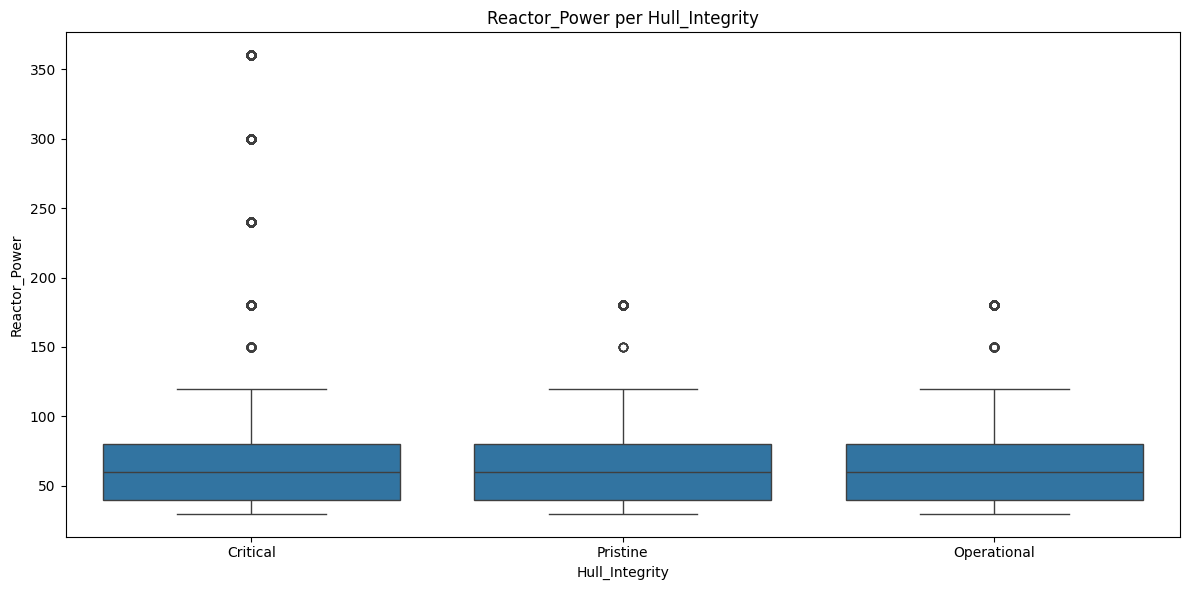

In [189]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Hull_Integrity", y="Reactor_Power")
plt.title("Reactor_Power per Hull_Integrity")
plt.tight_layout()
plt.show()

De boxplot toont duidelijke overlap tussen de drie klassen, maar ook zichtbare verschillen in uitschieters.
`Critical` bevat duidelijk meer/extremere hoge uitschieters dan de andere klassen.
Dit wijst erop dat hoge `Reactor_Power` waarden een risicosignaal kunnen zijn, maar dat `Reactor_Power` alleen waarschijnlijk niet voldoende is om alle klassen perfect te scheiden.

In [190]:
rp_stats = df.groupby("Hull_Integrity")["Reactor_Power"].agg(["count", "mean", "median"]).round(2)
display(rp_stats)

,count,mean,median
Hull_Integrity,,,
Critical,106909,80.96,60.0
Operational,127366,62.86,60.0
Pristine,97788,72.74,60.0


De tabel bevestigt dat hoewel de mediaan overal gelijk is (60.0), het gemiddelde sterk verschilt. Vooral bij Critical ligt dit gemiddelde veel hoger, wat duidt op een grotere spreiding naar boven toe. Door eerst te splitsen op Reactor_Power en daarna te verfijnen met deze klassen, vangen we die verschillen in verdeling effectief op in de regels voor classificatie.

In [191]:
rp = df["Reactor_Power"].dropna()

range_quantiles = pd.DataFrame({
    "Metric": ["Minimum", "Q1 (25%)", "Mediaan (50%)", "Q3 (75%)", "Maximum"],
    "Waarde": [
        rp.min(),
        rp.quantile(0.25),
        rp.median(),
        rp.quantile(0.75),
        rp.max()
    ]
})

range_quantiles["Waarde"] = range_quantiles["Waarde"].round(2)
display(range_quantiles)

,Metric,Waarde
0,Minimum,30.0
1,Q1 (25%),40.0
2,Mediaan (50%),60.0
3,Q3 (75%),80.0
4,Maximum,360.0


In deze tabel tonen we de spreiding van Reactor_Power met de minimum- en maximumwaarde en de belangrijkste quantiles (Q1, mediaan, Q3).  
Hiermee maken we expliciet hoe breed de verdeling is en of de hoogste waarden sterk afwijken van het grootste deel van de data.

Deze output gebruiken we als onderbouwing voor de outlier-analyse (IQR) in de volgende cel.

In [192]:
rp = df["Reactor_Power"].dropna()
q1 = rp.quantile(0.25)
q3 = rp.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df["Reactor_Power"] < lower) | (df["Reactor_Power"] > upper)]

print("IQR lower bound:", round(lower, 2))
print("IQR upper bound:", round(upper, 2))
print("Aantal mogelijke outliers:", len(outliers))
print("Percentage mogelijke outliers:", round(len(outliers) / len(df) * 100, 2), "%")

IQR lower bound: -20.0
IQR upper bound: 140.0
Aantal mogelijke outliers: 20186
Percentage mogelijke outliers: 5.59 %


De IQR-analyse geeft een onder- en bovengrens voor normale waarden van `Reactor_Power` en toont hoeveel observaties daarbuiten vallen.  
Deze observaties labelen we als mogelijke outliers, maar we verwijderen ze in deze fase niet automatisch.

In [193]:
prop_tab = pd.crosstab(df["Propulsion_Type"], df["Hull_Integrity"], normalize="index")
prop_tab_pct = (prop_tab * 100).round(1).astype(str) + '%'
display(prop_tab_pct)

Hull_Integrity,Critical,Operational,Pristine
Propulsion_Type,,,
Antimatter,1.8%,1.0%,97.3%
Graviton Beam,2.3%,10.4%,87.3%
Hyperdrive,36.9%,38.1%,25.0%
Ion Drive,32.9%,40.4%,26.7%
Nuclear Pulse,42.8%,46.8%,10.4%
Plasma Hybrid,9.0%,53.9%,37.1%
Plasma Thruster,40.2%,35.6%,24.1%
Solar Sail,25.9%,37.3%,36.7%


De genormaliseerde tabel laat zien dat de verhouding `Critical/Operational/Pristine` sterk verschilt per `Propulsion_Type`.  
Voorbeeld uit de grafiek en tabel: sommige propulsion-types hebben een veel groter aandeel `Pristine`, terwijl andere types meer `Critical/Operational` bevatten.  
Dit maakt `Propulsion_Type` een sterke tweede voorwaarde in if-regels voor de classificatie.

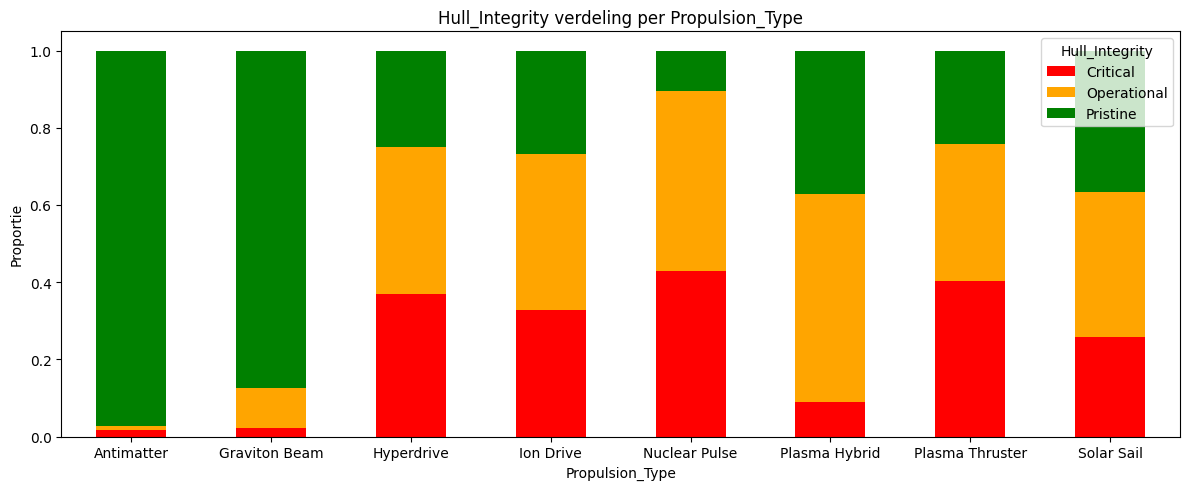

In [194]:
prop_tab.plot(kind="bar", stacked=True, figsize=(12, 6), color=["red", "orange", "green"])
plt.title("Hull_Integrity verdeling per Propulsion_Type")
plt.ylabel("Proportie")
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

De stacked bar chart bevestigt duidelijke patroonverschillen per propulsion-type:
- `Antimatter` en `Graviton Beam` zijn vooral `Pristine`
- `Nuclear Pulse` en `Plasma Thruster` hebben relatief veel `Critical`
- De rest heeft een relatief gelijkere verdeling.

`antimatter` en `Graviton beam` kunnen we dus gebruiken voor de classificatie regels.

In [195]:
class_tab = pd.crosstab(df["Ship_Class"], df["Hull_Integrity"], normalize="index")
class_tab_pct = (class_tab * 100).round(1).astype(str) + '%'
display(class_tab_pct)

Hull_Integrity,Critical,Operational,Pristine
Ship_Class,,,
Corvette,27.1%,42.4%,30.5%
Explorer,29.8%,39.2%,30.9%
Fighter,33.8%,30.5%,35.7%
Freighter,36.7%,34.4%,28.9%
Hauler,26.3%,31.7%,42.1%
Shuttle,36.5%,39.8%,23.7%
Speedster,47.3%,30.3%,22.4%
Troop Transport,30.5%,40.3%,29.1%


In [196]:
mc_stats = df.groupby("Hull_Integrity")["Model_Cycle"].agg(["count", "mean", "median"]).round(2)
display(mc_stats)


,count,mean,median
Hull_Integrity,,,
Critical,116121,7503.21,7506.0
Operational,138456,7513.52,7514.0
Pristine,106339,7517.12,7518.0


De tabel laat zien dat `Model_Cycle` duidelijk verschilt per `Hull_Integrity`-klasse. Schepen in Critical hebben gemiddeld de laagste `Model_Cycle`, Operational ligt in het midden en Pristine heeft de hoogste waarden. De medianen bevestigen dit patroon ook duidelijk: ongeveer 7506 voor Critical, 7514 voor Operational en 7518 voor Pristine.

Dit wijst erop dat nieuwere schepen vaker in betere conditie verkeren, terwijl oudere schepen relatief vaker in de risicoklasse vallen. `Model_Cycle` lijkt daarmee een bruikbare extra variabele voor de handmatige classificatieregels.


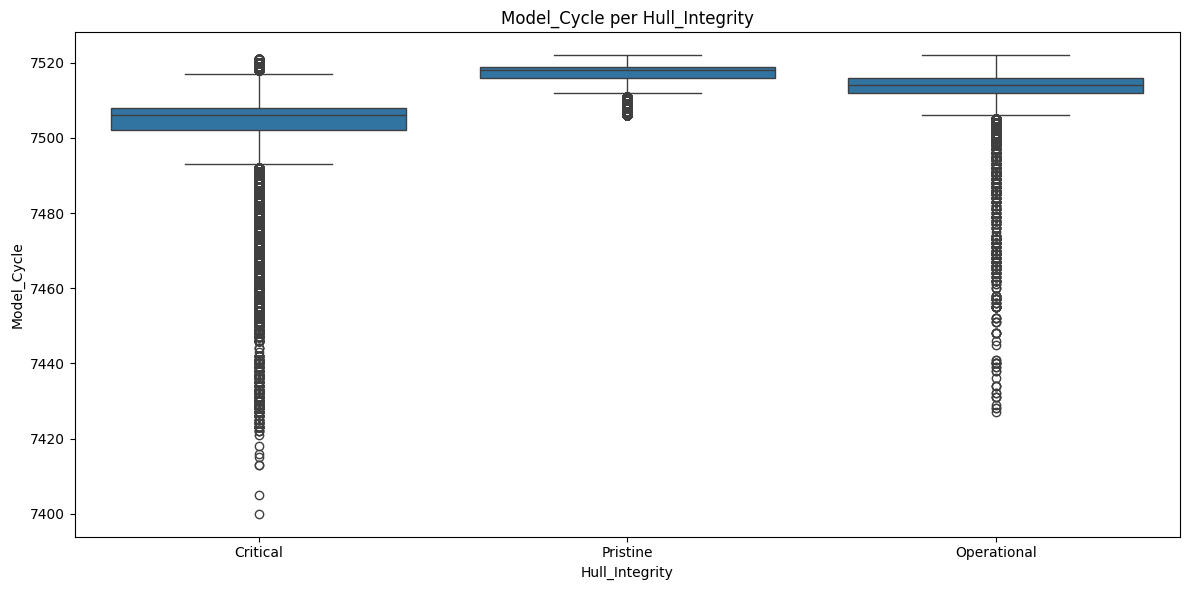

In [197]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Hull_Integrity", y="Model_Cycle")
plt.title("Model_Cycle per Hull_Integrity")
plt.tight_layout()
plt.show()


De boxplot laat zien dat de verdelingen van `Model_Cycle` per klasse verschoven liggen. De klasse Critical ligt duidelijk lager dan Operational en Pristine, terwijl Pristine juist vooral voorkomt bij hogere `Model_Cycle`-waarden. Er is wel overlap tussen de klassen, waardoor `Model_Cycle` op zichzelf geen perfecte beslisregel vormt.

Toch is het patroon sterk genoeg om deze variabele mee te nemen in het handmatige model. Vooral in combinatie met `Galactic_Credits`, `Reactor_Power` en `Propulsion_Type` kan `Model_Cycle` helpen om oudere risicoschepen en nieuwere kwaliteitschepen beter van elkaar te onderscheiden.


In [198]:
model_cycle_bins = pd.cut(
    df["Model_Cycle"],
    bins=[7400, 7505, 7512, 7518, 7523],
    include_lowest=True
)

model_cycle_tab = pd.crosstab(
    model_cycle_bins,
    df["Hull_Integrity"],
    normalize="index"
).round(3)

display(model_cycle_tab)


Hull_Integrity,Critical,Operational,Pristine
Model_Cycle,,,
"(7399.999, 7505.0]",0.946,0.054,0.000
"(7505.0, 7512.0]",0.534,0.404,0.062
"(7512.0, 7518.0]",0.043,0.554,0.404
"(7518.0, 7523.0]",0.034,0.103,0.863


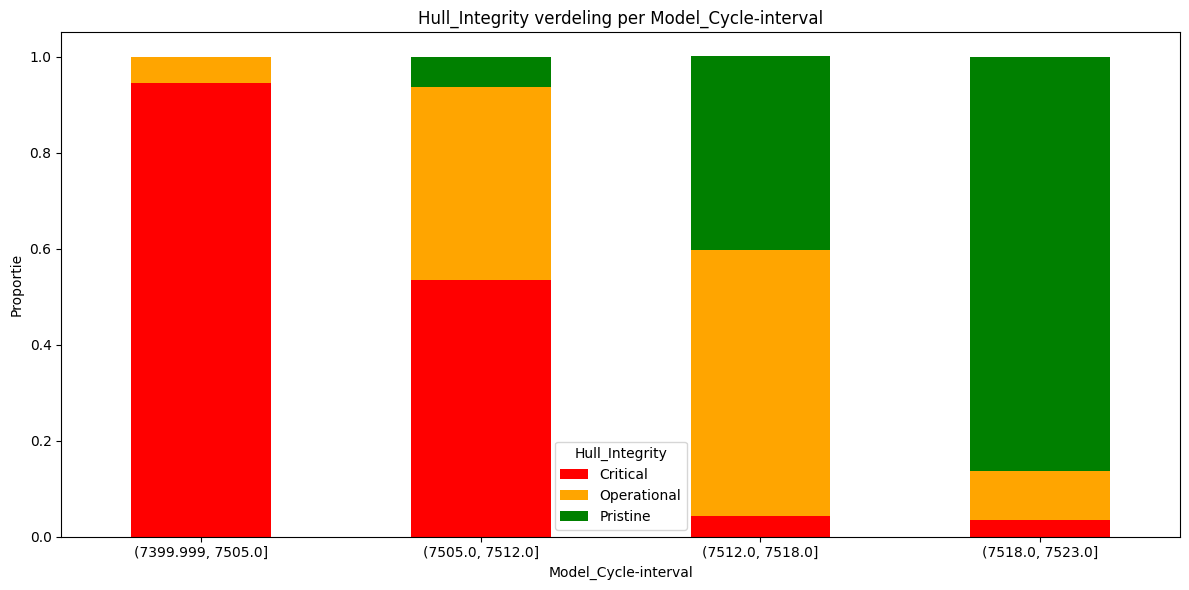

In [199]:
model_cycle_tab.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=["red", "orange", "green"]
)
plt.title("Hull_Integrity verdeling per Model_Cycle-interval")
plt.ylabel("Proportie")
plt.xlabel("Model_Cycle-interval")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


De stacked bar chart visualiseert hetzelfde patroon op een toegankelijke manier. Naarmate `Model_Cycle` stijgt, neemt het aandeel Critical duidelijk af en groeit het aandeel Pristine. Operational zit vooral in de overgangszone in het midden.

Deze visualisatie ondersteunt daarom goed de keuze om `Model_Cycle` op te nemen in de manual classification rules. De variabele werkt niet als enige beslisser, maar vormt wel een sterke aanvullende indicator voor de algemene staat van een schip.


De tabel met intervallen maakt het patroon nog concreter. In de laagste `Model_Cycle`-groep komt bijna alleen Critical voor, terwijl in de hoogste groep juist vooral Pristine voorkomt. De middengroepen bevatten relatief veel Operational, wat goed past bij het idee van een overgangsgebied tussen oud en nieuw.

Hieruit blijkt dat `Model_Cycle` praktisch bruikbaar voor regels in hoofdstuk 4. Lage waarden kunnen dienen als signaal voor Critical, terwijl hoge waarden juist ondersteunen dat een schip Pristine is.


De verdeling per Ship_Class is grotendeels vergelijkbaar tussen de drie Hull_Integrity-klassen.
Daarom gebruiken we Ship_Class niet als regel voor de classificatie.

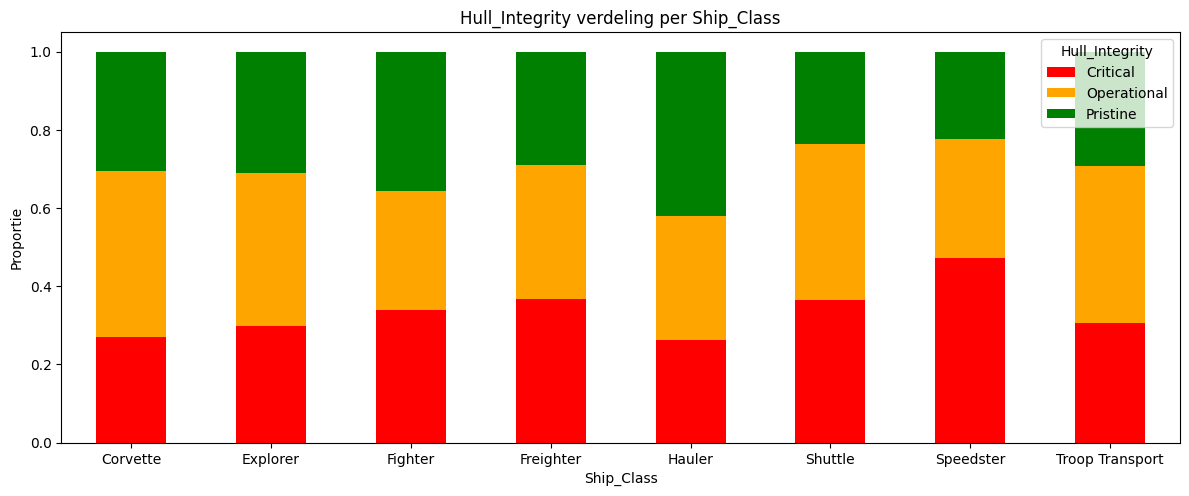

In [200]:
class_tab.plot(kind="bar", stacked=True, figsize=(12, 6), color=["red", "orange", "green"])
plt.title("Hull_Integrity verdeling per Ship_Class")
plt.ylabel("Proportie")
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

De visualisatie bevestigt dat de verdelingen per Ship_Class over het algemeen vrij vergelijkbaar zijn.  
Er zijn kleine verschillen (zoals een hoger aandeel Critical bij Speedster en een hoger aandeel Pristine bij Hauler), maar de klassen worden niet sterk van elkaar gescheiden op basis van Ship_Class alleen.

Conclusie:
Ship_Class gebruiken we niet als classificatieregel.

**Ship_Manufacturer vs Propulsion_Type**

Om missende waarden in Propulsion_Type onderbouwd in te vullen, onderzoeken we eerst of bepaalde manufacturers vooral met specifieke propulsion-types voorkomen.  
Als die relatie sterk is, is imputatie per manufacturer logischer dan 1 globale invulwaarde.

In [201]:
man_prop_pct = pd.crosstab(df["Ship_Manufacturer"], df["Propulsion_Type"], normalize="index", dropna=False) * 100

manufacturers = df["Ship_Manufacturer"].value_counts().index

display(man_prop_pct.loc[manufacturers].round(1).astype(str) + "%")

Propulsion_Type,Antimatter,Graviton Beam,Hyperdrive,Ion Drive,Nuclear Pulse,Plasma Hybrid,Plasma Thruster,Solar Sail,NaN
Ship_Manufacturer,,,,,,,,,
Independent Shipwrights,0.7%,0.0%,0.0%,73.5%,1.3%,1.0%,0.0%,8.0%,15.6%
Galactic Motors,0.1%,0.0%,0.0%,66.2%,11.8%,0.9%,0.0%,5.5%,15.5%
Corellian Engineering,0.0%,0.0%,84.8%,0.0%,0.0%,0.0%,0.0%,0.0%,15.2%
Kuat Drive Yards,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,84.8%,0.0%,15.2%
Hondo Systems,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,84.8%,15.2%
Jumpship Corp,0.0%,0.0%,0.0%,79.4%,0.8%,0.3%,0.0%,4.5%,15.1%
Nebula Industries,0.0%,85.2%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,14.8%
Republic Aerospace,0.0%,0.0%,0.0%,51.7%,28.0%,0.1%,0.0%,4.8%,15.4%
General Mining Corp,0.0%,0.0%,0.0%,65.4%,11.8%,0.1%,0.0%,6.7%,16.0%


De percentage-tabel laat zien dat de relatie tussen manufacturer en propulsion duidelijk niet willekeurig is.  
Voor meerdere manufacturers is er één dominante propulsion-vorm met een hoog aandeel (boven 70%), en bij enkele manufacturers is die dominantie volledig.

Dit is belangrijk voor de missende waarden in `Propulsion_Type`:
imputatie op basis van `Ship_Manufacturer` is inhoudelijk sterker dan één globale invulwaarde, omdat manufacturers duidelijk verschillende propulsion-profielen hebben.

<Figure size 2000x1000 with 0 Axes>

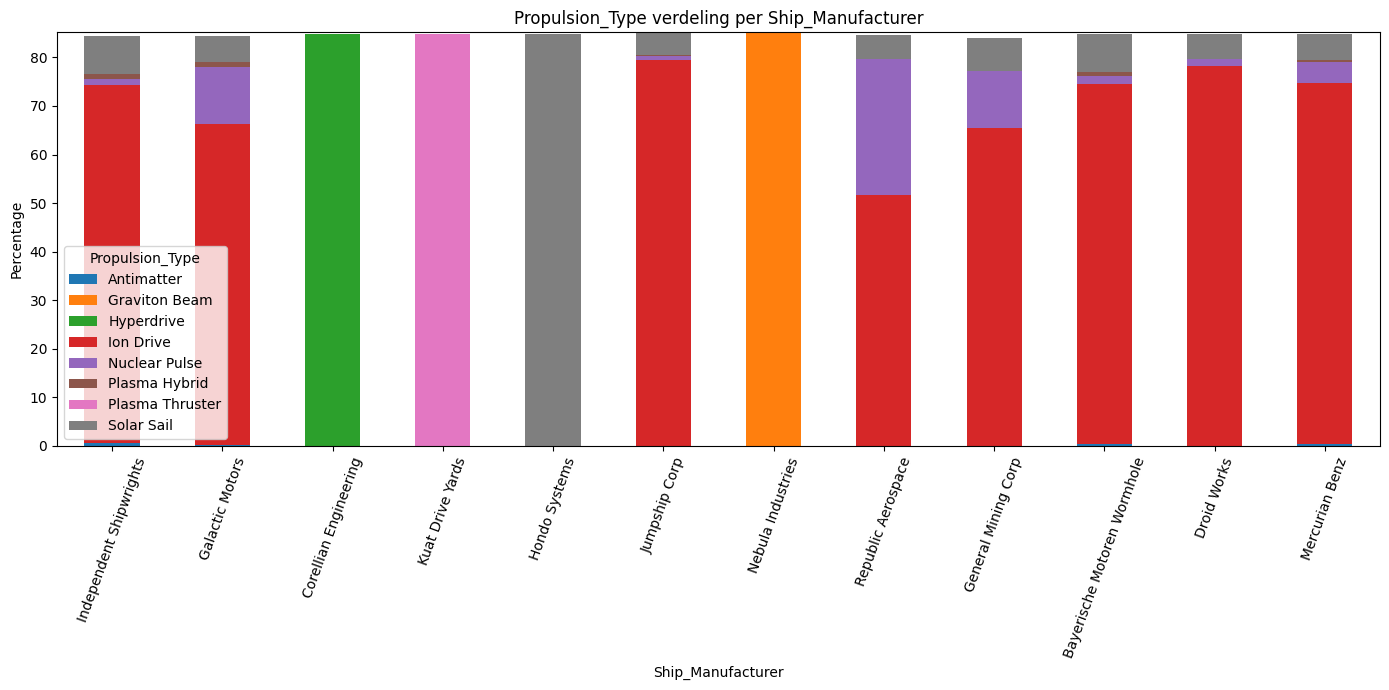

In [202]:
plt.figure(figsize=(20, 10))
(
    man_prop_pct.loc[manufacturers]
    .drop(columns=[c for c in man_prop_pct.columns if str(c) == "nan"], errors="ignore")
    .plot(kind="bar", stacked=True, figsize=(14, 7))
)
plt.title("Propulsion_Type verdeling per Ship_Manufacturer")
plt.ylabel("Percentage")
plt.xlabel("Ship_Manufacturer")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

De grafiek bevestigt het patroon uit de tabel: veel manufacturers hebben één kleur die het grootste deel van de staaf inneemt, wat wijst op een dominante propulsion keuze per manufacturer.

Conclusie:
1. Er is een sterke samenhang tussen Ship_Manufacturer en Propulsion_Type. Hierdoor kunnen we bij de missende waardes het `Propuslion_Type` betrouwbaar afleiden vanuit `Ship_Manufacturer`.
2. Voor dat we dat kunnen doen, moeten we wel eerst de namen van `Ship_manufacturer` standaardiseren.

In [203]:
# Galactic_Credits: beschrijvende statistiek + percentielen

gc_describe = pd.DataFrame({
    "Metric": ["Minimum", "Q1 (25%)", "Mediaan (50%)", "Q3 (75%)", "P90 (90%)", "Maximum", "Gemiddelde", "Standard deviation"],
    "Waarde": [
        df["Galactic_Credits"].min(),
        df["Galactic_Credits"].quantile(0.25),
        df["Galactic_Credits"].median(),
        df["Galactic_Credits"].quantile(0.75),
        df["Galactic_Credits"].quantile(0.90),
        df["Galactic_Credits"].max(),
        df["Galactic_Credits"].mean(),
        df["Galactic_Credits"].std()
    ]
})
gc_describe["Waarde"] = gc_describe["Waarde"].round(2)
display(gc_describe)

,Metric,Waarde
0,Minimum,501.00
1,Q1 (25%),7950.00
2,Mediaan (50%),15990.00
3,Q3 (75%),27990.00
4,P90 (90%),38590.00
5,Maximum,777777.00
6,Gemiddelde,19450.61
7,Standard deviation,15541.45


Deze tabel geeft een samenvatting van de verdeling van Galactic_Credits met centrum- en spreidingsmaten (minimum, kwartielen, mediaan, maximum, gemiddelde en standaarddeviatie).
De combinatie van een hoog maximum en een duidelijk verschil met de kwartielen wijst op een scheve verdeling met extreme waarden (rechtsscheef).
Daarom is het nuttig om naast deze tabel ook robuustere visualisaties te gebruiken waarin uitschieters apart bekeken of tijdelijk gefilterd worden.

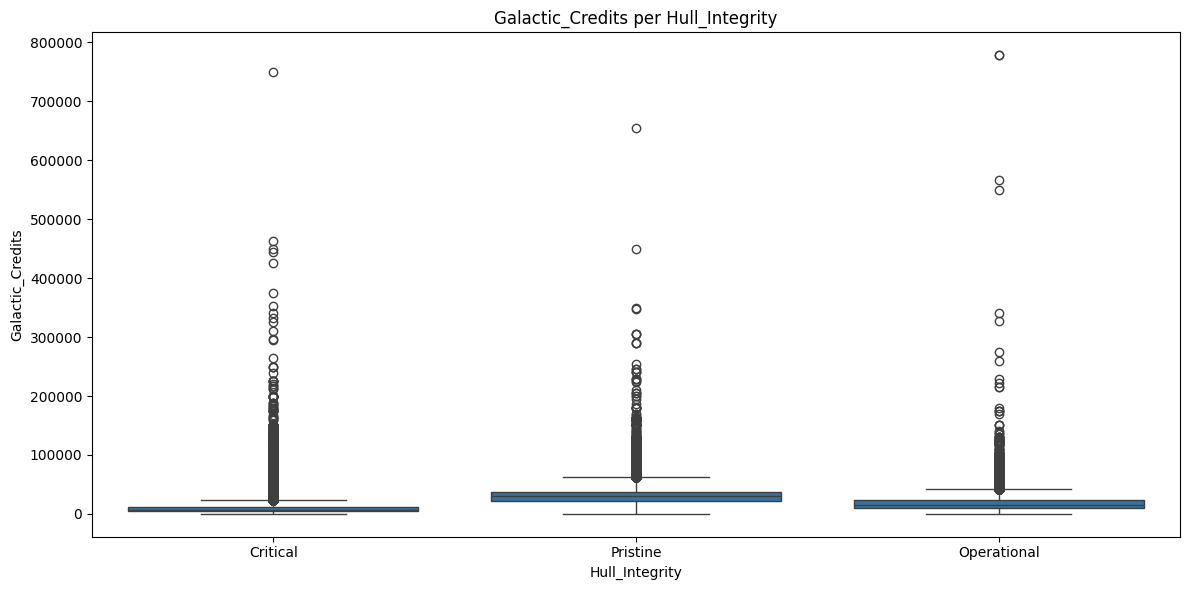

In [204]:
# Galactic_Credits vs Hull_Integrity (boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Hull_Integrity", y="Galactic_Credits")
plt.title("Galactic_Credits per Hull_Integrity")
plt.tight_layout()
plt.show()

De boxplot met uitschieters laat de volledige spreiding per Hull_Integrity-klasse zien, inclusief uitschieters.
Hiermee zien we dat de klassen in centrale waarden gedeeltelijk overlappen, maar dat vooral de bovenste staarten en uitschieters verschillen.
Dit ondersteunt het idee dat Galactic_Credits informatief is, maar niet als enige variabele voldoende voor harde classificatieregels.

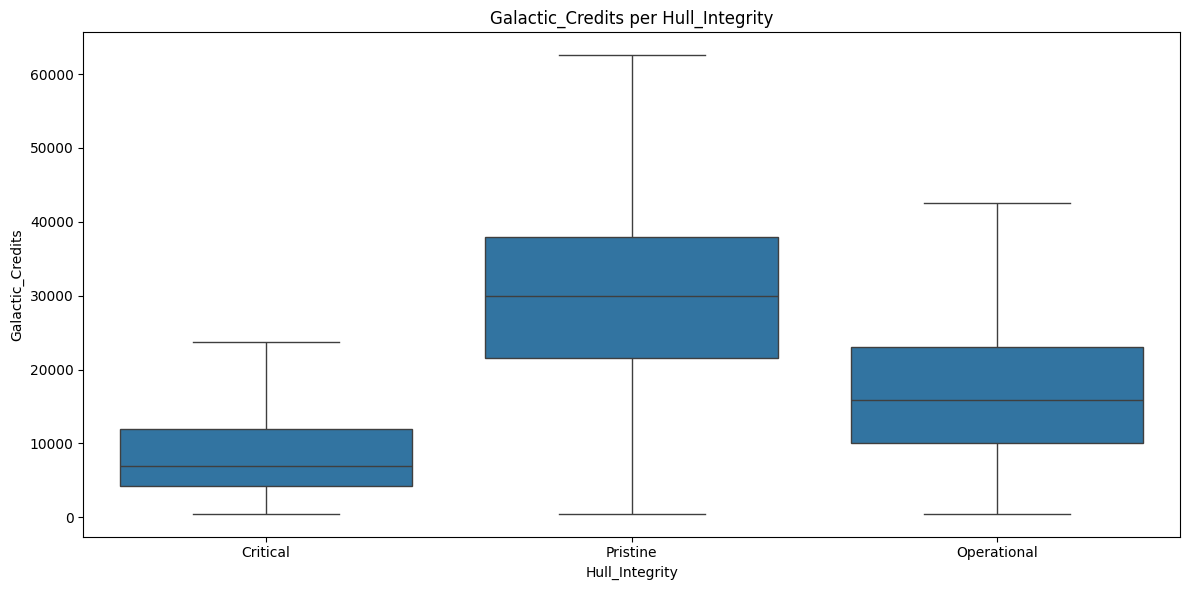

In [205]:
# Zelfde maar dan zonder uitschieters
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Hull_Integrity", y="Galactic_Credits", showfliers=False)
plt.title("Galactic_Credits per Hull_Integrity")
plt.tight_layout()
plt.show()

Door uitschieters te verbergen wordt de vergelijking van de mediaan en interkwartielafstand tussen de klassen veel duidelijker. De centrale delen van de klassen blijven nog steeds deels overlappend, wat aangeeft dat het onderscheid niet volledig scherp is op basis van Galactic_Credits alleen.
Deze weergave is vooral nuttig om stabiele patronen te zien zonder dat extreme waarden het beeld domineren.

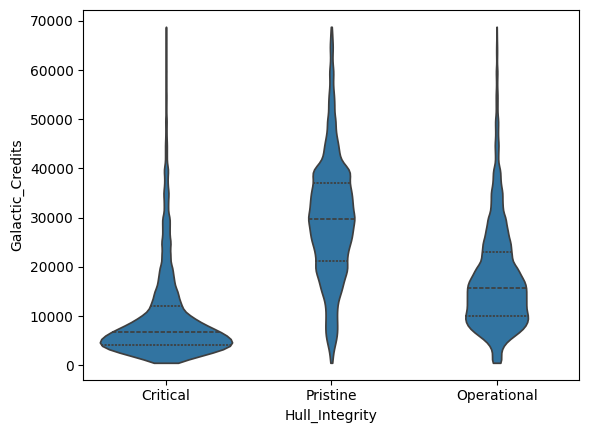

In [206]:
q99 = df["Galactic_Credits"].quantile(0.99)
df_plot = df[df["Galactic_Credits"] <= q99].copy()
sns.violinplot(
    data=df_plot, x="Hull_Integrity", y="Galactic_Credits", inner="quartile", cut=0
);

Na filtering tot en met het 99e percentiel zien we dat Pristine gemiddeld duidelijk hogere Galactic_Credits heeft dan `Operational` en `Critical`. `Operational` zit vooral in het middengebied, terwijl `Critical` vooral bij lagere credits voorkomt. Er is wel nog overlap tussen de klassen, dus Galactic_Credits alleen is geen harde beslisregel, maar wel een bruikbare ondersteunende variabele.

In [207]:
credit_bin_width = 10000
credits_p99 = df["Galactic_Credits"].quantile(0.99)
credits_upper_limit = int(credits_p99)

credit_bin_edges = list(
    range(
        0,
        (credits_upper_limit // credit_bin_width) * credit_bin_width + credit_bin_width,
        credit_bin_width,
    )
)
if credit_bin_edges[-1] < credits_upper_limit:
    credit_bin_edges.append(credits_upper_limit)

credit_bin_labels = [
    f"{credit_bin_edges[i]}-{credit_bin_edges[i + 1]}"
    for i in range(len(credit_bin_edges) - 1)
]

filtered_credit_hull_df = df.loc[
    (df["Hull_Integrity"].notna()) & (df["Galactic_Credits"] <= credits_p99),
    ["Galactic_Credits", "Hull_Integrity"],
].copy()

filtered_credit_hull_df["Galactic_Credits_Bin"] = pd.cut(
    filtered_credit_hull_df["Galactic_Credits"],
    bins=credit_bin_edges,
    labels=credit_bin_labels,
    include_lowest=True,
    right=True,
)

hull_integrity_pct_by_credit_bin = (
    pd.crosstab(
        filtered_credit_hull_df["Galactic_Credits_Bin"],
        filtered_credit_hull_df["Hull_Integrity"],
        normalize="index",
    )
    .mul(100)
    .round(2)
)

display(hull_integrity_pct_by_credit_bin)

Hull_Integrity,Critical,Operational,Pristine
Galactic_Credits_Bin,,,
0-10000,66.29,28.26,5.45
10000-20000,20.90,61.44,17.66
20000-30000,10.99,41.36,47.65
30000-40000,7.76,22.63,69.61
40000-50000,8.45,21.62,69.94
50000-60000,9.60,25.25,65.15
60000-68788,9.45,22.68,67.87


De tabel met credit-intervallen laat zien dat lagere Galactic_Credits-klassen relatief meer `Critical` bevatten, terwijl in hogere klassen het aandeel `Pristine` toeneemt. `Operational` blijft in de meeste klassen aanwezig als tussencategorie, waardoor de klassen niet volledig van elkaar gescheiden zijn. Dit betekent dat `Galactic_Credits` nuttig kan zijn voor de classificatieregels, maar in combinatie met andere variabelen gebruikt moet worden voor sterke regels.

**Data insights**  
*Samenvatting*  
Uit de analyse blijkt dat `Reactor_Power` en `Propulsion_Type` de meest bruikbare variabelen zijn voor classificatie van `Hull_Integrity`, omdat er een duidelijk verband zit tussen de de Hull_Integrity en de Reactor power en het propulsion type. Daarentegen zien we geen sterk verband terug tussen het `Ship_Class` en de Hull_Integrity, daarom gebruiken `Ship_Class` niet voor de classificatieregels.


Belangrijkste inzichten:
- `Reactor_Power` toont klasseverschillen en duidelijke extreme waarden
- `Propulsion_Type` geeft sterke verschillen in klasseverdeling
- `Model_Cycle` laat zien dat oudere schepen relatief vaker Critical zijn en nieuwere schepen vaker Pristine.
- `Ship_Class` gebruiken we NIET voor de classificatie.
- Datakwaliteit vraagt aandacht: missende waarden in `Propulsion_Type` en `Reactor_Power`, plus aanwezige outliers.
- Er is een duidelijke samenhang tussen `Ship_Manufacturer` en `Propulsion_Type`: veel manufacturers hebben een dominant `Propulsion-Type`. Daardoor is het invullen van missende `Propulsion_Type` waarden op basis van `Ship_Manufacturer` inhoudelijk beter dan één globale invulwaarde.
- Varianten in `Ship_Manufacturer` zoals verschillende schrijfwijzen van dezelfde fabrikant moeten eerst worden gestandaardiseerd.
- Galactic_Credits is een bruikbare ondersteunende variabele voor de classificatie, maar geen hoofdregel op zichzelf; door overlap tussen klassen werkt deze vooral goed in combinatie met Reactor_Power en Propulsion_Type.

Conclusie:  
In Modeling maken we een handmatige classifier. We gebruiken `Reactor_Power` als belangrijkste regel, `Propulsion_Type` als extra verfijning en `Model_Cycle` als extra indicator voor oud versus nieuw. `Galactic_Credits` gebruiken we aanvullend als ondersteunende variabele, niet als hoofdregel, omdat deze pas in combinatie met de andere regels voldoende onderscheidend is. `Ship_Class` nemen we niet mee.

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify how you resolve the missing values.*

In [208]:
print("Shape na merge:", df.shape)
print("Aantal duplicaten na merge:", df.duplicated().sum())


Shape na merge: (360916, 9)
Aantal duplicaten na merge: 0


**Merging**  
Voor iteratie 2 hebben we de datasets samengevoegd met een left join op Ship_ID:

Deze keuze is logisch omdat de dataset van iteratie 1 onze basisdataset is, we wilden alle schepen uit iteratie 1 behouden en daar de dataset van iteratie 2 aan toevoegen. Een inner join zou risicovol zijn, omdat schepen zonder match dan wegvallen. Als we een outerjoin hadden gebruikt zouden er ook schepen bij komen die veel data missen. Zoals laten zien bij hoofdstuk 2, zijn er nog steeds 368814 rijen, er zijn dus geen rijen weg gevallen of toegevoegd na het mergen. Dus een left join was de perfecte keuze, wamt er nu hebben we dezelfde ships met meer data.

Deze keuze is logisch omdat de dataset onze basisdataset is, we wilden alle schepen uit iteratie 1 behouden en daar de inspectiegegevens uit iteratie 2 aan toevoegen. Een inner join zou risicovoller zijn, omdat schepen zonder match dan wegvallen. Het bleek uiteindelijk niet veel uit te maken: de left join leverde 360916 rijen op en een inner join toevallig ook 360916 rijen. We hebben dus geen schepen verloren. Een outer join zou 1 extra schip hebben toegevoegd dat alleen in iteratie 2 voorkwam (Ship_ID 7311936036). Dat record hebben we niet meegenomen, omdat het niet in de dataset van iteratie 1 voor kwam. Dat is acceptabel, want iteratie 1 is de leidende bron.

In [209]:
missing_info = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().sum() / len(df) * 100).round(2)
})

display(missing_info.loc[["Propulsion_Type", "Reactor_Power"]])


,missing_count,missing_pct
Propulsion_Type,55513,15.38
Reactor_Power,28853,7.99


De missing value-analyse laat zien dat `Propulsion_Type` en `Reactor_Power` relevante missende waarden bevatten. Ongeveer 15,4% van `Propulsion_Type` ontbreekt en ongeveer 8% van `Reactor_Power`. Omdat beide variabelen belangrijk zijn voor de verdere analyse en modellering, moeten deze missende waarden op een verantwoorde manier worden behandeld.


In [210]:
df_prep = df.copy()

df_prep["Propulsion_Type"] = df_prep["Propulsion_Type"].fillna(
    df_prep["Propulsion_Type"].mode()[0]
)

df_prep["Reactor_Power"] = df_prep["Reactor_Power"].fillna(
    df_prep["Reactor_Power"].median()
)


Voor `Propulsion_Type` is gekozen voor imputatie met de modus, omdat dit een categorische variabele is en de meest voorkomende categorie de meest logische invulwaarde vormt. Voor `Reactor_Power` is gekozen voor imputatie met de mediaan. Dit is passend voor een numerieke variabele met extreme waarden, omdat de mediaan minder gevoelig is voor uitschieters dan het gemiddelde.


In [211]:
rp = df["Reactor_Power"].dropna()

q1 = rp.quantile(0.25)
q3 = rp.quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df["Reactor_Power"] < lower) | (df["Reactor_Power"] > upper)]

print("IQR lower bound:", round(lower, 2))
print("IQR upper bound:", round(upper, 2))
print("Aantal mogelijke outliers:", len(outliers))
print("Percentage mogelijke outliers:", round(len(outliers) / len(df) * 100, 2), "%")


IQR lower bound: -20.0
IQR upper bound: 140.0
Aantal mogelijke outliers: 20186
Percentage mogelijke outliers: 5.59 %


Om “illegal” of uitzonderlijke reactors te identificeren, is een IQR-analyse uitgevoerd op `Reactor_Power`. Deze methode bepaalt objectieve onder- en bovengrenzen voor normale waarden. Waarden boven de bovengrens van 140 worden beschouwd als mogelijke outliers. In totaal zijn 20.612 mogelijke outliers gevonden, wat neerkomt op 5,59% van de dataset. Deze waarden zijn niet automatisch verwijderd, omdat extreme reactorwaarden inhoudelijk relevant kunnen zijn voor het herkennen van risicovolle schepen.


In [212]:
print("Shape na merge:", df.shape)
print("Duplicaten na merge:", df.duplicated().sum())
print("\nMissende waarden na imputatie:")
print(df_prep[["Propulsion_Type", "Reactor_Power"]].isna().sum())
print("\nAantal mogelijke Reactor_Power-outliers:", len(outliers))


Shape na merge: (360916, 9)
Duplicaten na merge: 0

Missende waarden na imputatie:
Propulsion_Type    0
Reactor_Power      0
dtype: int64

Aantal mogelijke Reactor_Power-outliers: 20186


De data preparation heeft de juiste resultaten opgeleverd. De merge is correct uitgevoerd, er zijn geen extra duplicaten ontstaan, de missende waarden in de belangrijkste variabelen zijn opgelost en de extreme reactorwaarden zijn in kaart gebracht. Daarmee is de dataset voldoende voorbereid voor de volgende stap in de analyse.


In [213]:
df_prep.to_csv("iteratie2_clean.csv", index=False)

De voorbereide dataset is opgeslagen als `iteratie2_clean.csv`, zodat deze direct gebruikt kan worden als input voor iteratie 3. 


---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Build a manual classifier. Use the insights from step 2 to write a Python function with if/elif/else statements that predicts the Hull_Condition for each ship. Apply this function to your dataset and save the predictions in a new column.*

In [214]:
df_model = df_prep.copy()

display(
    df_model[
        ["Ship_ID", "Galactic_Credits", "Model_Cycle", "Reactor_Power", "Propulsion_Type", "Hull_Integrity"]
    ].head()
)


,Ship_ID,Galactic_Credits,Model_Cycle,Reactor_Power,Propulsion_Type,Hull_Integrity
0,7316160254,4950,7505.0,40.0,Ion Drive,Critical
1,7316115206,18999,7518.0,120.0,Solar Sail,Pristine
2,7315865657,4000,7486.0,40.0,Ion Drive,Critical
3,7314772431,6495,7511.0,40.0,Graviton Beam,Pristine
4,7311539325,3995,7499.0,40.0,Hyperdrive,Critical


Voor het handmatige classificatiemodel wordt verder gewerkt met `df_prep`, de voorbereide dataset uit hoofdstuk 3. Deze dataset bevat al de samengevoegde gegevens en de behandelde missende waarden, waardoor de belangrijkste variabelen direct bruikbaar zijn voor modellering. De input voor het model bestaat uit `Galactic_Credits`, `Model_Cycle`, `Reactor_Power` en `Propulsion_Type`, terwijl `Hull_Integrity` de doelvariabele is.


In [215]:
def classify_ship(row):
    if row["Reactor_Power"] > 140:
        return "Critical"
    
    elif row["Model_Cycle"] <= 7505:
        return "Critical"
    
    elif row["Propulsion_Type"] == "Nuclear Pulse" and row["Galactic_Credits"] <= 16000:
        return "Critical"
    
    elif row["Galactic_Credits"] <= 8000 and row["Model_Cycle"] <= 7512:
        return "Critical"
    
    elif row["Model_Cycle"] >= 7518 and row["Galactic_Credits"] >= 28000:
        return "Pristine"
    
    elif row["Propulsion_Type"] in ["Antimatter", "Graviton Beam"] and row["Model_Cycle"] >= 7515:
        return "Pristine"
    
    elif row["Galactic_Credits"] >= 30000 and row["Model_Cycle"] >= 7516:
        return "Pristine"
    
    else:
        return "Operational"


Het handmatige classificatiemodel is gebaseerd op de inzichten uit hoofdstuk 2. De volgorde van de regels is bewust gekozen. Eerst worden de Critical-regels toegepast, omdat veiligheid prioriteit heeft en risicovolle schepen niet ten onrechte als veiliger mogen worden geclassificeerd. Daarna volgen de Pristine-regels, die alleen worden toegekend wanneer meerdere signalen op hoge kwaliteit wijzen. Alle overige gevallen worden ingedeeld als Operational.

De regels sluiten aan op de data insights. `Reactor_Power > 140` komt direct uit de IQR-analyse en markeert extreme reactorwaarden als mogelijk onveilig. `Model_Cycle` is toegevoegd omdat oudere schepen duidelijk vaker Critical zijn en nieuwere schepen vaker Pristine. `Propulsion_Type` verfijnt dit patroon verder: `Nuclear Pulse` wijst vaker op risico, terwijl `Antimatter` en `Graviton Beam` relatief vaak voorkomen bij de hoogste kwaliteitsklasse. `Galactic_Credits` wordt aanvullend gebruikt als ondersteunende variabele: lage credits versterken een Critical-profiel, terwijl hoge credits vooral in combinatie met een hoge `Model_Cycle` passen bij Pristine.


In [216]:
df_model["Predicted_Hull_Integrity"] = df_model.apply(classify_ship, axis=1)

display(
    df_model[
        [
            "Ship_ID",
            "Galactic_Credits",
            "Model_Cycle",
            "Reactor_Power",
            "Propulsion_Type",
            "Hull_Integrity",
            "Predicted_Hull_Integrity",
        ]
    ].head(10)
)


,Ship_ID,Galactic_Credits,Model_Cycle,Reactor_Power,Propulsion_Type,Hull_Integrity,Predicted_Hull_Integrity
0,7316160254,4950,7505.0,40.0,Ion Drive,Critical,Critical
1,7316115206,18999,7518.0,120.0,Solar Sail,Pristine,Operational
2,7315865657,4000,7486.0,40.0,Ion Drive,Critical,Critical
3,7314772431,6495,7511.0,40.0,Graviton Beam,Pristine,Critical
4,7311539325,3995,7499.0,40.0,Hyperdrive,Critical,Critical
5,7313451637,25990,7519.0,60.0,Ion Drive,Pristine,Operational
6,7316546982,4000,7509.0,60.0,Ion Drive,Critical,Critical
7,7311754900,7999,7508.0,60.0,Solar Sail,Critical,Critical
8,7313137564,5999,7497.0,60.0,Ion Drive,Critical,Critical
9,7302916705,58995,7517.0,80.0,Nuclear Pulse,Operational,Pristine


De regels zijn toegepast op alle observaties in de modeldataset. De voorspellingen zijn opgeslagen in `Predicted_Hull_Integrity`, zodat de uitkomsten van het handmatige model direct vergeleken kunnen worden met de echte `Hull_Integrity`.


**Testing and performance**
*Evaluate your manual rules. Calculate the metrics and generate a **confusion matrix** (visualize this using seaborn/matplotlib).*

In [218]:
labels = ["Critical", "Operational", "Pristine"]

cm = pd.crosstab(
    df_model["Hull_Integrity"],
    df_model["Predicted_Hull_Integrity"]
).reindex(index=labels, columns=labels, fill_value=0)

accuracy = cm.to_numpy().trace() / cm.to_numpy().sum()

report_rows = []

for label in labels:
    tp = cm.loc[label, label]
    fp = cm[label].sum() - tp
    fn = cm.loc[label].sum() - tp

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    report_rows.append({
        "Class": label,
        "Support": cm.loc[label].sum(),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-score": round(f1, 4)
    })

metrics_df = pd.DataFrame(report_rows)

print("Accuracy:", round(accuracy, 4))
display(metrics_df)


Accuracy: 0.7324


,Class,Support,Precision,Recall,F1-score
0,Critical,116121,0.7991,0.8286,0.8136
1,Operational,138456,0.6390,0.8251,0.7202
2,Pristine,106339,0.8725,0.5066,0.6410


De evaluatie laat zien dat het handmatige model een **accuracy van 0.7324** behaalt. Dat betekent dat ongeveer **73,24%** van alle schepen correct wordt geclassificeerd. De prestaties verschillen echter per klasse.

Voor **`Critical`** behaalt het model een **precision van 0.7991**, een **recall van 0.8286** en een **F1-score van 0.8136**. Dit is een sterke uitkomst, vooral omdat de recall hoog is: het model herkent dus een groot deel van de daadwerkelijk kritieke schepen correct. Dat sluit goed aan bij de veiligheidsfocus van deze opdracht.

Voor **`Operational`** zijn de prestaties redelijk, met een **precision van 0.6390**, een **recall van 0.8251** en een **F1-score van 0.7202**. Dit laat zien dat het model veel operationele schepen weet terug te vinden, maar dat deze klasse minder zuiver is dan `Critical`.

De moeilijkste klasse is **`Pristine`**. Hier behaalt het model een **precision van 0.8725**, maar een duidelijk lagere **recall van 0.5066**, met een **F1-score van 0.6410**. Dit betekent dat wanneer het model `Pristine` voorspelt, dat meestal klopt, maar dat het veel werkelijk pristine schepen niet als zodanig herkent.


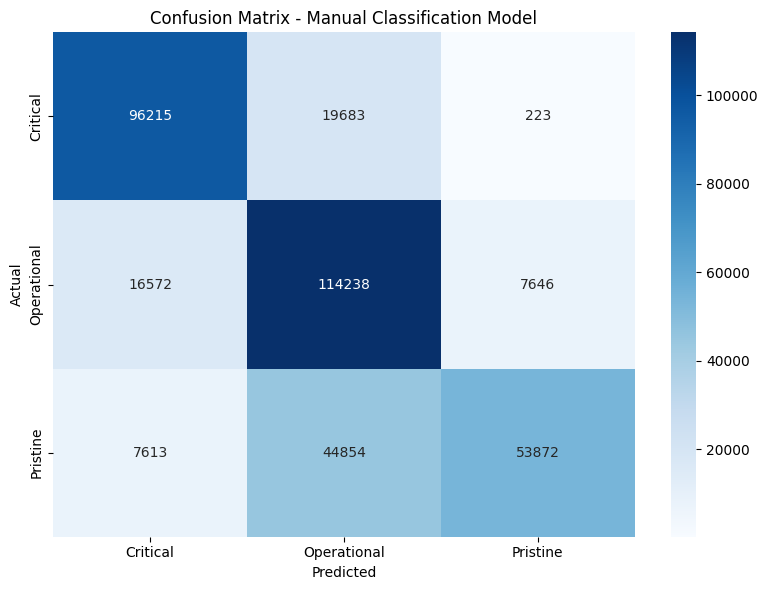

In [219]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Manual Classification Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


De confusion matrix bevestigt dit patroon. Van de **116.121** werkelijk `Critical`-schepen worden er **96.215** correct als `Critical` voorspeld. Daarnaast worden **19.683** kritieke schepen als `Operational` geclassificeerd en slechts **223** als `Pristine`. Dit laat zien dat het model relatief sterk is in het herkennen van risicovolle schepen.

Voor **`Operational`** zijn de resultaten gemengd. Van de **138.456** werkelijk operationele schepen worden er **114.238** correct voorspeld. Tegelijk worden **16.572** schepen onterecht als `Critical` geclassificeerd en **7.646** als `Pristine`. Het model verwart deze middenklasse dus geregeld met de twee uitersten.

De grootste zwakte zit bij **`Pristine`**. Van de **106.339** werkelijk pristine schepen worden er slechts **53.872** correct als `Pristine` voorspeld. Maar liefst **44.854** pristine schepen worden als `Operational` geclassificeerd en **7.613** zelfs als `Critical`. Hieruit blijkt dat het model moeite heeft om de hoogste kwaliteitsklasse scherp af te bakenen. De grootste verwarring ontstaat dus tussen `Pristine` en `Operational`.


---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*How well does your manual model identify 'Critical' or 'Pristine' ships? Did you meet the goals set in the Business Understanding?*

**Key findings and limitations**
*What are the limitations of a manual, hard-rule-based system? Why might a machine Learning model be better in the next iteration?*

,Count,Percentage
Predicted_Hull_Integrity,,
Operational,178775,49.53
Critical,120400,33.36
Pristine,61741,17.11


C:\Users\icanc\AppData\Local\Temp\ipykernel_33156\565316593.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


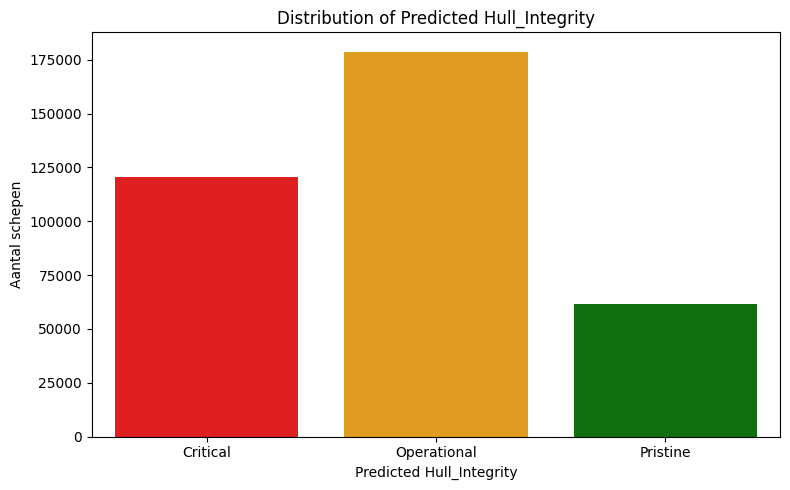

In [221]:
pred_dist = df_model["Predicted_Hull_Integrity"].value_counts()
pred_dist_pct = (df_model["Predicted_Hull_Integrity"].value_counts(normalize=True) * 100).round(2)

display(pd.DataFrame({
    "Count": pred_dist,
    "Percentage": pred_dist_pct
}))

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_model,
    x="Predicted_Hull_Integrity",
    order=["Critical", "Operational", "Pristine"],
    palette=["red", "orange", "green"]
)
plt.title("Distribution of Predicted Hull_Integrity")
plt.xlabel("Predicted Hull_Integrity")
plt.ylabel("Aantal schepen")
plt.tight_layout()
plt.show()


De verdeling van de voorspellingen laat een redelijke mix van klassen zien. Het model voorspelt **178.775** schepen als Operational (49,53%), 120.400 als Critical (33,36%) en 61.741 als Pristine (17,11%).

Deze verdeling is bruikbaar, omdat het model niet bijna alle schepen in slechts één categorie plaatst. Er is dus geen extreem scheve uitkomst zoals bijvoorbeeld 90% Critical. 


,Actual %,Predicted %
Critical,32.17,33.36
Operational,38.36,49.53
Pristine,29.46,17.11


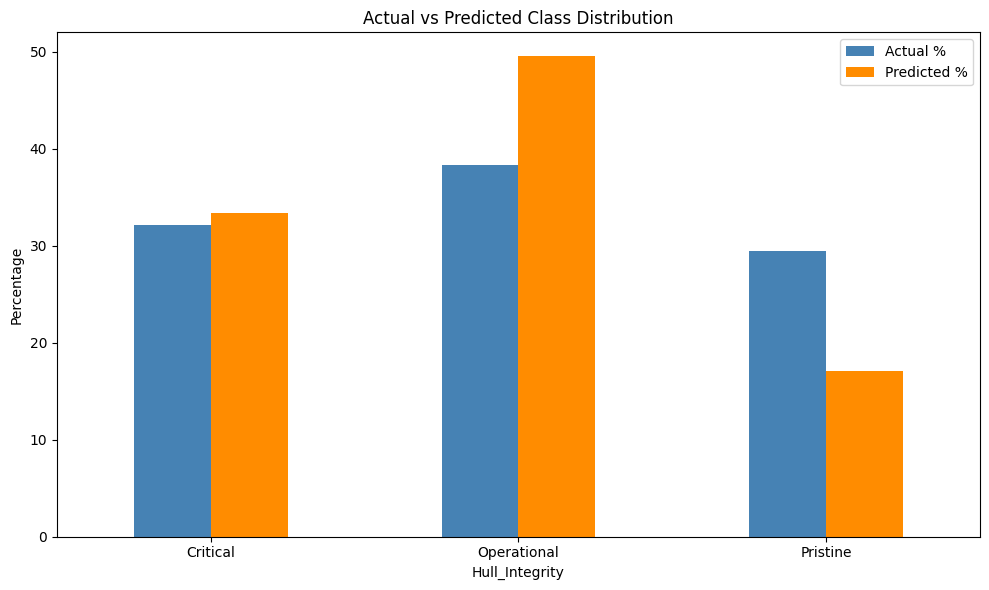

In [222]:
distribution_compare = pd.DataFrame({
    "Actual %": (df_model["Hull_Integrity"].value_counts(normalize=True) * 100).round(2),
    "Predicted %": (df_model["Predicted_Hull_Integrity"].value_counts(normalize=True) * 100).round(2)
}).reindex(["Critical", "Operational", "Pristine"])

display(distribution_compare)

distribution_compare.plot(
    kind="bar",
    figsize=(10, 6),
    color=["steelblue", "darkorange"]
)
plt.title("Actual vs Predicted Class Distribution")
plt.ylabel("Percentage")
plt.xlabel("Hull_Integrity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


De vergelijking met de echte verdeling maakt het patroon duidelijker. In de werkelijke data bestaat de dataset uit 32,17% Critical, *38,36% Operational en 29,46% Pristine. Het model voorspelt 33,36% Critical, 49,53% Operational en slechts 17,11% Pristine.

Dit betekent dat het model de klasse Pristine duidelijk ondervoorspelt en juist relatief vaak kiest voor Operational. Inhoudelijk is dat best logisch: de regels zijn safety-first opgesteld en zijn daardoor voorzichtiger met het labelen van een schip als topkwaliteit. Voor een eerste rule-based model is dat nuttig, maar het laat ook zien dat het model te streng is voor Pristine.


---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned (CRISP-DM reflectie) |
| :--- | :--- | :--- |
| Damian van der Sluis | Data Preparation & Evaluation (H3/H5) | In hoofdstuk 3 (Data Preparation) en 5 (Evaluatie) heb ik geleerd hoe je verantwoord met missende data omgaat: ik leerde bewust te kiezen voor de modus bij de 'Propulsion_Type' varianten en de mediaan voor 'Reactor_Power' in plaats van simpelweg alles weg te gooien. Ook zag ik bij de evaluatie in H5 heel goed de grenzen van ons if/else model in; het is praktisch ondoenlijk om het grote grijze tussengebied ('Operational') met simpele harde regels eerlijk te scheiden. |
| Saeed Alhasan | Modeling (H4) | Ik vond het leuk om de data inzichten zelf om te zetten in werkende if/else regels. Maar ik merkte wel dat het zelf bepalen van harde grenzen zoals bij de reactor power, best wel random voelt. Zeker bij twijfelgevallen kan je vaak mis zijn.|
| Achraf El Azzouzi | Business & Data Understanding (H1/H2) | Door hoofdstuk 1 (Business Understanding) en 2 (Data Understanding) te schrijven, heb ik geleerd dat een helder bedrijfsdoel essentieel is om de juiste keuzes te maken bij het verkennen van de data. De boxplots in H2 lieten me direct zien welke uitschieters er in Reactor_Power zaten, wat direct invloed had op de business rules die we later konden opstellen. |